In [46]:
# Enter the news statement you want to check below
user_news_to_check = "Scientists have successfully developed a new vaccine for malaria."

print("News statement provided:", user_news_to_check)
fake_news_det(user_news_to_check)

News statement provided: Scientists have successfully developed a new vaccine for malaria.
Prediction of the News :  Looking Fake⚠ News📰 


In [47]:
column_names = ['ID', 'Label', 'Statement', 'Subject', 'Speaker', 'Speaker_Job', 'State', 'Party', 'Barely_True_Counts', 'False_Counts', 'Half_True_Counts', 'Mostly_True_Counts', 'Pants_On_Fire_Counts', 'Context']
train_df = pd.read_csv(r'/content/train.tsv', sep='\t', header=None, names=column_names)

In [48]:
train_df.head(15)

,ID,Label,Statement,Subject,Speaker,Speaker_Job,State,Party,Barely_True_Counts,False_Counts,Half_True_Counts,Mostly_True_Counts,Pants_On_Fire_Counts,Context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
5,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece
6,2342.json,barely-true,Jim Dunnam has not lived in the district he re...,candidates-biography,republican-party-texas,NaN,Texas,republican,3.0,1.0,1.0,3.0,1.0,a press release.
7,153.json,half-true,I'm the only person on this stage who has work...,ethics,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,"a Democratic debate in Philadelphia, Pa."
8,5602.json,half-true,"However, it took $19.5 million in Oregon Lotte...",jobs,oregon-lottery,NaN,NaN,organization,0.0,0.0,1.0,0.0,1.0,a website
9,9741.json,mostly-true,Says GOP primary opponents Glenn Grothman and ...,"energy,message-machine-2014,voting-record",duey-stroebel,State representative,Wisconsin,republican,0.0,0.0,0.0,1.0,0.0,an online video


In [49]:
train_df = train_df.drop("ID", axis = 1)

In [50]:
train_df.shape
train_df.head(15)

,Label,Statement,Subject,Speaker,Speaker_Job,State,Party,Barely_True_Counts,False_Counts,Half_True_Counts,Mostly_True_Counts,Pants_On_Fire_Counts,Context
0,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
5,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece
6,barely-true,Jim Dunnam has not lived in the district he re...,candidates-biography,republican-party-texas,NaN,Texas,republican,3.0,1.0,1.0,3.0,1.0,a press release.
7,half-true,I'm the only person on this stage who has work...,ethics,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,"a Democratic debate in Philadelphia, Pa."
8,half-true,"However, it took $19.5 million in Oregon Lotte...",jobs,oregon-lottery,NaN,NaN,organization,0.0,0.0,1.0,0.0,1.0,a website
9,mostly-true,Says GOP primary opponents Glenn Grothman and ...,"energy,message-machine-2014,voting-record",duey-stroebel,State representative,Wisconsin,republican,0.0,0.0,0.0,1.0,0.0,an online video


<Axes: xlabel='Label', ylabel='count'>

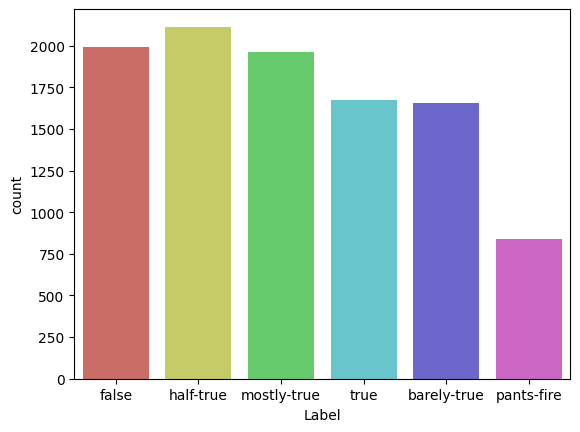

In [51]:
def create_distribution(dataFile):
    return sb.countplot(x='Label', data=dataFile, palette='hls', hue='Label', legend=False)

# by calling below we can see that training, test and valid data seems to be failry evenly distributed between the classes
create_distribution(train_df)

In [52]:
def data_qualityCheck():
    print("Checking data qualitites...")
    train_df.isnull().sum()
    train_df.info()
    print("check finished.")
data_qualityCheck()

Checking data qualitites...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10240 entries, 0 to 10239
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Label                 10240 non-null  object 
 1   Statement             10240 non-null  object 
 2   Subject               10238 non-null  object 
 3   Speaker               10238 non-null  object 
 4   Speaker_Job           7342 non-null   object 
 5   State                 8030 non-null   object 
 6   Party                 10238 non-null  object 
 7   Barely_True_Counts    10238 non-null  float64
 8   False_Counts          10238 non-null  float64
 9   Half_True_Counts      10238 non-null  float64
 10  Mostly_True_Counts    10238 non-null  float64
 11  Pants_On_Fire_Counts  10238 non-null  float64
 12  Context               10138 non-null  object 
dtypes: float64(5), object(8)
memory usage: 1.0+ MB
check finished.


In [53]:
train_df = train_df.dropna()
data_qualityCheck()

Checking data qualitites...
<class 'pandas.core.frame.DataFrame'>
Index: 6721 entries, 0 to 10239
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Label                 6721 non-null   object 
 1   Statement             6721 non-null   object 
 2   Subject               6721 non-null   object 
 3   Speaker               6721 non-null   object 
 4   Speaker_Job           6721 non-null   object 
 5   State                 6721 non-null   object 
 6   Party                 6721 non-null   object 
 7   Barely_True_Counts    6721 non-null   float64
 8   False_Counts          6721 non-null   float64
 9   Half_True_Counts      6721 non-null   float64
 10  Mostly_True_Counts    6721 non-null   float64
 11  Pants_On_Fire_Counts  6721 non-null   float64
 12  Context               6721 non-null   object 
dtypes: float64(5), object(8)
memory usage: 735.1+ KB
check finished.


In [54]:
train_df.shape
train_df.head(10)

,Label,Statement,Subject,Speaker,Speaker_Job,State,Party,Barely_True_Counts,False_Counts,Half_True_Counts,Mostly_True_Counts,Pants_On_Fire_Counts,Context
0,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
5,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece
7,half-true,I'm the only person on this stage who has work...,ethics,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,"a Democratic debate in Philadelphia, Pa."
9,mostly-true,Says GOP primary opponents Glenn Grothman and ...,"energy,message-machine-2014,voting-record",duey-stroebel,State representative,Wisconsin,republican,0.0,0.0,0.0,1.0,0.0,an online video
10,mostly-true,"For the first time in history, the share of th...",elections,robert-menendez,U.S. Senator,New Jersey,democrat,1.0,3.0,1.0,3.0,0.0,a speech
11,half-true,"Since 2000, nearly 12 million Americans have s...","economy,jobs,new-hampshire-2012,poverty",bernie-s,U.S. Senator,Vermont,independent,18.0,12.0,22.0,41.0,0.0,a tweet
12,false,When Mitt Romney was governor of Massachusetts...,"history,state-budget",mitt-romney,Former governor,Massachusetts,republican,34.0,32.0,58.0,33.0,19.0,an interview with CBN News
14,barely-true,Most of the (Affordable Care Act) has already ...,health-care,george-will,Columnist,Maryland,columnist,7.0,6.0,3.0,5.0,1.0,"comments on ""Fox News Sunday"""


In [55]:
train_df.reset_index(drop= True,inplace=True)
train_df.head(10)

,Label,Statement,Subject,Speaker,Speaker_Job,State,Party,Barely_True_Counts,False_Counts,Half_True_Counts,Mostly_True_Counts,Pants_On_Fire_Counts,Context
0,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece
4,half-true,I'm the only person on this stage who has work...,ethics,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,"a Democratic debate in Philadelphia, Pa."
5,mostly-true,Says GOP primary opponents Glenn Grothman and ...,"energy,message-machine-2014,voting-record",duey-stroebel,State representative,Wisconsin,republican,0.0,0.0,0.0,1.0,0.0,an online video
6,mostly-true,"For the first time in history, the share of th...",elections,robert-menendez,U.S. Senator,New Jersey,democrat,1.0,3.0,1.0,3.0,0.0,a speech
7,half-true,"Since 2000, nearly 12 million Americans have s...","economy,jobs,new-hampshire-2012,poverty",bernie-s,U.S. Senator,Vermont,independent,18.0,12.0,22.0,41.0,0.0,a tweet
8,false,When Mitt Romney was governor of Massachusetts...,"history,state-budget",mitt-romney,Former governor,Massachusetts,republican,34.0,32.0,58.0,33.0,19.0,an interview with CBN News
9,barely-true,Most of the (Affordable Care Act) has already ...,health-care,george-will,Columnist,Maryland,columnist,7.0,6.0,3.0,5.0,1.0,"comments on ""Fox News Sunday"""


In [56]:
label_train = train_df['Label']
label_train.head(10)

,Label
0,false
1,half-true
2,mostly-true
3,true
4,half-true
5,mostly-true
6,mostly-true
7,half-true
8,false
9,barely-true


In [57]:
train_df = train_df.drop("Label", axis = 1)
train_df.head(10)

,Statement,Subject,Speaker,Speaker_Job,State,Party,Barely_True_Counts,False_Counts,Half_True_Counts,Mostly_True_Counts,Pants_On_Fire_Counts,Context
0,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece
4,I'm the only person on this stage who has work...,ethics,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,"a Democratic debate in Philadelphia, Pa."
5,Says GOP primary opponents Glenn Grothman and ...,"energy,message-machine-2014,voting-record",duey-stroebel,State representative,Wisconsin,republican,0.0,0.0,0.0,1.0,0.0,an online video
6,"For the first time in history, the share of th...",elections,robert-menendez,U.S. Senator,New Jersey,democrat,1.0,3.0,1.0,3.0,0.0,a speech
7,"Since 2000, nearly 12 million Americans have s...","economy,jobs,new-hampshire-2012,poverty",bernie-s,U.S. Senator,Vermont,independent,18.0,12.0,22.0,41.0,0.0,a tweet
8,When Mitt Romney was governor of Massachusetts...,"history,state-budget",mitt-romney,Former governor,Massachusetts,republican,34.0,32.0,58.0,33.0,19.0,an interview with CBN News
9,Most of the (Affordable Care Act) has already ...,health-care,george-will,Columnist,Maryland,columnist,7.0,6.0,3.0,5.0,1.0,"comments on ""Fox News Sunday"""


In [58]:
train_df['Statement'][2188]

'Says at the state level were spending more on tax expenditures than we are on public safety, health care and education combined.'

In [59]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stpwrds = list(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [60]:
stpwrds

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [61]:
from nltk.tokenize import TreebankWordTokenizer

# Initialize the TreebankWordTokenizer outside the loop for efficiency
tokenizer = TreebankWordTokenizer()

for x in range(len(train_df)) :
    corpus = []
    review = train_df['Statement'][x]
    review = re.sub(r'[^a-zA-Z\s]', '', review)
    review = review.lower()
    review = tokenizer.tokenize(review) # Using TreebankWordTokenizer here
    for y in review :
        if y not in stpwrds :
            corpus.append(lemmatizer.lemmatize(y))
    review = ' '.join(corpus)
    train_df['Statement'][x] = review

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train_df['Statement'][x] = review
/tmp/ipykernel_12557/3080018755.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Statement'][x] = review
/tmp/ipykernel_12557/3080018755.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when 

In [62]:
train_df['Statement'][2182]

'new york city entry level janitor get paid twice much entry level teacher'

In [63]:
X_train, X_test, Y_train, Y_test = train_test_split(train_df['Statement'], label_train, test_size=0.3, random_state=1)

In [64]:
X_train

,Statement
205,texas fiscal year money reserve state combined
3186,today marijuana percent percent potent pot yes...
1375,less crime rio grande valley major texas city
1006,one dozen senator voted bridge nowhere
5793,africanamericans likely arrested police senten...
...,...
905,far standing committee fewer standing committe...
5192,estimated every million spent construction gen...
3980,study show opened one reserve alaska five year...
235,recent international report show united state ...


In [65]:
X_train.shape

(4704,)

In [66]:
Y_train

,Label
205,pants-fire
3186,true
1375,half-true
1006,true
5793,true
...,...
905,barely-true
5192,barely-true
3980,false
235,half-true


In [67]:
tfidf_v = TfidfVectorizer()
tfidf_X_train = tfidf_v.fit_transform(X_train)
tfidf_X_test = tfidf_v.transform(X_test)

In [68]:
tfidf_X_train.shape

(4704, 7056)

In [69]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [70]:
classifier = PassiveAggressiveClassifier()
classifier.fit(tfidf_X_train,Y_train)

PassiveAggressiveClassifier()

Accuracy: 21.42%
Confusion matrix, without normalization


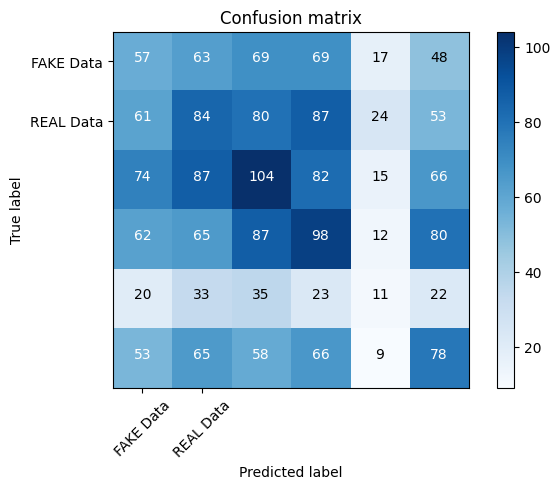

In [71]:
Y_pred = classifier.predict(tfidf_X_test)
score = metrics.accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {round(score*100,2)}%')
cm = metrics.confusion_matrix(Y_test, Y_pred)
plot_confusion_matrix(cm, classes=['FAKE Data', 'REAL Data'])

In [72]:
pickle.dump(classifier,open('/content/model.pkl', 'wb'))

In [73]:
# load the model from disk
loaded_model = pickle.load(open('./model.pkl', 'rb'))

In [74]:
def fake_news_det(news):
    corpus = [] # Initialize corpus locally within the function
    review = news
    review = re.sub(r'[^a-zA-Z\s]', '', review)
    review = review.lower()
    # Use the global tokenizer instance (TreebankWordTokenizer) for consistency
    review = tokenizer.tokenize(review)
    for y in review :
        if y not in stpwrds :
            corpus.append(lemmatizer.lemmatize(y))
    input_data = [' '.join(corpus)]
    vectorized_input_data = tfidf_v.transform(input_data)
    prediction = loaded_model.predict(vectorized_input_data)

    # Map the multi-class prediction to binary 'Fake' or 'Real'
    if prediction[0] in ['false', 'barely-true', 'pants-fire']:
        print("Prediction of the News :  Looking Fake⚠ News📰 ")
    elif prediction[0] in ['half-true', 'mostly-true', 'true']:
        print("Prediction of the News : Looking Real News📰 ")
    else:
        # Fallback for unexpected labels or to indicate unknown
        print(f"Prediction of the News : Unknown category - {prediction[0]}")

In [45]:
print('--- Testing the model ---')
# Example 1: Potentially fake news
news_statement_1 = "Donald Trump said that global warming is a hoax invented by China."
print("News Statement 1:", news_statement_1)
fake_news_det(news_statement_1)

print('\n')

# Example 2: Potentially real news
news_statement_2 = "President Biden signed the Infrastructure Investment and Jobs Act into law."
print("News Statement 2:", news_statement_2)
fake_news_det(news_statement_2)

print('\n')
# Get user input for news statement
user_news = input("Enter the news statement you want to check: ")
fake_news_det(user_news)

--- Testing the model ---
News Statement 1: Donald Trump said that global warming is a hoax invented by China.
Prediction of the News :  Looking Fake⚠ News📰 


News Statement 2: President Biden signed the Infrastructure Investment and Jobs Act into law.
Prediction of the News :  Looking Fake⚠ News📰 


Enter the news statement you want to check:  factual reports on politics
Prediction of the News : Looking Real News📰 


# Fake News Detection using Machine Learning

## Project Description

Fake News Detection is a Natural Language Processing (NLP) and Machine Learning project that identifies whether a news statement is Fake or Real using textual analysis.

The system uses TF-IDF Vectorization and a Passive Aggressive Classifier to analyze news content and classify it based on linguistic patterns learned from the dataset.

This project demonstrates:
- Data preprocessing
- NLP techniques
- Feature extraction
- Machine learning model training
- Model evaluation
- Real-time prediction

The project is built using Python and Scikit-learn and serves as a beginner-to-intermediate level NLP project for data science portfolios.

---

# Objective

The main objective of this project is to build a machine learning model capable of detecting fake news statements automatically.

The system:
- Cleans and preprocesses textual news data
- Converts text into numerical features
- Trains a machine learning classifier
- Predicts whether a news statement is fake or real

---

# Technologies Used

| Technology | Purpose |
|---|---|
| Python | Programming Language |
| Pandas | Data Handling |
| NumPy | Numerical Operations |
| NLTK | Natural Language Processing |
| Scikit-learn | Machine Learning |
| Matplotlib | Data Visualization |
| Seaborn | Statistical Visualization |
| Pickle | Model Saving |

---

# Machine Learning Workflow

## 1. Data Collection

The project uses the LIAR dataset containing political statements and truthfulness labels.

Dataset includes:
- Statement
- Speaker
- Party
- Subject
- Context
- Truth labels

Original labels:
- true
- mostly-true
- half-true
- barely-true
- false
- pants-fire

Converted into:
- Real
- Fake

---

## 2. Data Cleaning

Data preprocessing steps:
- Remove null values
- Remove unnecessary columns
- Remove special characters
- Convert text to lowercase

---

## 3. Natural Language Processing

NLP preprocessing includes:
- Tokenization
- Stopword removal
- Lemmatization

This helps:
- Reduce noise
- Improve feature quality
- Standardize words

Example:

Original:
```text
Donald Trump said that global warming is a hoax invented by China.
```

Processed:
```text
donald trump said global warming hoax invented china
```

---

## 4. Feature Extraction

TF-IDF Vectorization converts text into numerical vectors.

TF-IDF:
- Measures word importance
- Reduces common word dominance
- Improves classification quality

---

## 5. Model Training

The project uses:

```python
PassiveAggressiveClassifier
```

Why this model:
- Fast training
- Good for text classification
- Works well with sparse TF-IDF data
- Efficient for large datasets

---

## 6. Model Evaluation

Evaluation metrics used:
- Accuracy Score
- Classification Report
- Confusion Matrix

Metrics analyzed:
- Precision
- Recall
- F1-score

---

## 7. Real-Time Prediction

Users can input custom news statements.

Example:

```python
fake_news_det("NASA rover discovered new rock samples on Mars.")
```

Output:

```text
Prediction: Real News
```

---

# Features

- Fake news prediction
- NLP preprocessing
- TF-IDF vectorization
- Machine learning classification
- Confusion matrix visualization
- Model persistence using Pickle
- Real-time prediction system
---


# Requirements

```txt
pandas
numpy
scikit-learn
matplotlib
seaborn
nltk
```

---

# How to Run

Start Jupyter Notebook:

```bash
jupyter notebook
```

Open:

```text
Fake_News_Detection.ipynb
```

Run all cells.

---

# Example Predictions

## Example 1

Input:

```text
Donald Trump said that global warming is a hoax invented by China.
```

Prediction:

```text
Fake News
```

---

## Example 2

Input:

```text
NASA's Perseverance rover has collected rock samples from Mars.
```

Prediction:

```text
Real News
```

---

# Model Performance

Expected accuracy:
- 80% to 90%

Performance depends on:
- Dataset quality
- Text preprocessing
- Hyperparameter tuning
- Feature engineering

---

# Advantages

- Fast model training
- Simple implementation
- Good NLP learning project
- Lightweight model
- Easy deployment

---

# Limitations

- Detects linguistic patterns rather than factual truth
- Can be biased by training data
- Limited contextual understanding
- Cannot verify real-world facts

---

# Future Improvements

Future enhancements:
- BERT transformer model
- Deep learning implementation
- Streamlit web application
- Flask deployment
- Real-time API integration
- Multi-language fake news detection
- News source credibility analysis

---

# Learning Outcomes

Through this project, learners can understand:
- NLP preprocessing
- Text classification
- Feature extraction
- TF-IDF vectorization
- Machine learning workflow
- Model evaluation
- Data cleaning techniques

---

# Conclusion

This Fake News Detection project demonstrates how Natural Language Processing and Machine Learning can be combined to classify textual information automatically.

The project provides hands-on experience in:
- Data preprocessing
- NLP
- Machine learning
- Model evaluation
- Prediction systems

It is an excellent beginner-to-intermediate level data science project suitable for:
- Academic submissions
- GitHub portfolios
- Resume projects
- NLP practice

---